# LabAst577 - Observational Astronomy
# Notebook with some basic data reduction and analysis with python

## First, import necessary libraries

In [ ]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
from astropy.io import fits

## Shift image to align with another

In [ ]:
#First load two other images:
dir="/content/sample_data/"
data1 = fits.getdata(dir+'altair_Blue_0012.fits')
data2 = fits.getdata(dir+'altair_Blue_0013.fits')
head1 = fits.getheader(dir+'altair_Blue_0012.fits')
head2 = fits.getheader(dir+'altair_Blue_0013.fits')

In [ ]:
## Obtain rough position with the mouse
pos1 = [948,354]
pos2 = [1013,811]

In [ ]:
!pip install photutils #only needed if its being run on colabs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 11.6 MB/s eta 0:00:00


[943.39675752 356.14027512] [1005.41739477  808.5221482 ]
[945.3091874  355.59233562] [1008.55154943  809.78534088]


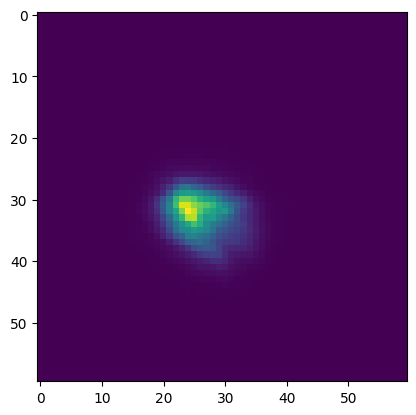

In [ ]:
## Get centroid
from photutils.centroids import centroid_com, centroid_2dg  #load centroid libraries
subdata1 = data1[pos1[1]-30:pos1[1]+30,pos1[0]-30:pos1[0]+30]#select subportion of 60x60 image
subdata2 = data2[pos2[1]-30:pos2[1]+30,pos2[0]-30:pos2[0]+30]#select subportion of 60x60 image
plt.imshow(subdata1)
center1,center2 = centroid_2dg(subdata1)+pos1-[30,30],centroid_2dg(subdata2)+pos2-[30,30]
ccenter1,ccenter2 = centroid_com(subdata1)+pos1-[30,30],centroid_com(subdata2)+pos2-[30,30]
print(center1,center2)
print(ccenter1,ccenter2)

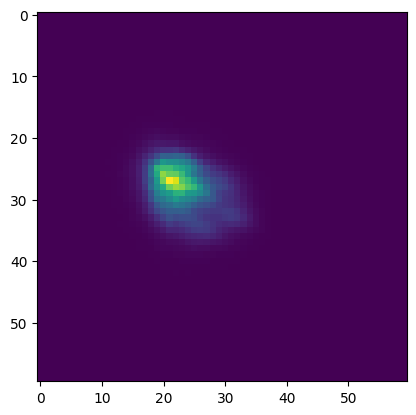

In [ ]:
plt.imshow(subdata2)

In [ ]:
## Shift image
shiftdat = np.roll(data2,-int(np.round(center2[1]-center1[1])),axis=0) #shift in y
shiftdata2 = np.roll(shiftdat,-int(np.round(center2[0]-center1[0])),axis=1) #shift in x

In [ ]:
## Save image
head2['PROCESS'] = 'shifted'
fits.writeto(dir+'altair_Blue_shifted.fits',shiftdata2,head2,overwrite=True)

In [ ]:
from scipy.ndimage import shift
#Shift withou roll over
shiftdat=shift(data2, (-int(np.round(center2[1]-center1[1])),-int(np.round(center2[0]-center1[0]))))

In [ ]:
## Save image
head2['PROCESS'] = 'shifted'
fits.writeto(dir+'altair_Blue_shifted_2.fits',shiftdat,head2,overwrite=True)

## Other tools

### Better alignment:
https://github.com/toros-astro/astroalign

### RGB color composite:
http://docs.astropy.org/en/stable/visualization/rgb.html

### To do aperture photometry:
https://photutils.readthedocs.io/en/stable/aperture.html

### To do PSF photometry:
https://photutils.readthedocs.io/en/stable/psf.html

### To do surface photometry:
https://photutils.readthedocs.io/en/stable/isophote.html

### To analyze time-series:
https://docs.astropy.org/en/stable/timeseries/

### On model fitting:
https://emcee.readthedocs.io/en/stable/tutorials/line/